In [18]:
import pandas as pd
df = pd.read_csv("/Users/gauurab/Documents/Projects/Distillation.John-O-Bryan/qwen_tuned_results_200iterations.csv")
df

,year,section,question_id,question,true_answer,agent1_answer,agent1_reasoning,distilled_reasoning,agent2_verdict,agent2_justification,correct_flag,qwen_response,qwen_extracted_answer,deepseek_verdict
0,2011,freshman_sophomore_test,question_1,A convex polygon has 19 sides. Find the sum of...,3060,3060,"We are given: ""A convex polygon has 19 sides. ...","The polygon has 19 sides, so n = 19. \nThe su...",CORRECT,The student's answer matches the correct answe...,1,To find the sum of the interior angles of a co...,3060,CORRECT
1,2011,freshman_sophomore_test,question_2,"If (x^2 - y^2) = 0 and x + y = 17.534, find th...",0,0,We are given: (x^2 - y^2) = 0 and x + y = 17.5...,\(x^2 - y^2 = 0\). \nFactor as \((x - y)(x + ...,CORRECT,The equation x^2 - y^2 = 0 implies (x-y)(x+y)=...,1,Given the equations:\n\n1. \(x^2 - y^2 = 0\)\n...,0,CORRECT
2,2011,freshman_sophomore_test,question_3,Two circles are constructed such that one has ...,16,16,"We are given: ""Two circles are constructed suc...",Find the radius of the second circle from its ...,CORRECT,The student's answer matches the correct answe...,1,"To solve the problem, we need to determine the...",\frac{1}{16},INCORRECT
3,2011,freshman_sophomore_test,question_4,"Casey invested part of $100,000 in bonds that ...",68000,68000,"We are given: ""Casey invested part of $100,000...",Let \( x \) be the amount in bonds and \( y \)...,CORRECT,The student's answer matches the correct numer...,1,Let's denote the amount Casey invested in bond...,"So, Casey invested $68,000 in certificates.",CORRECT
4,2011,freshman_sophomore_test,question_6,A bag of shapes contains the following polygon...,2/3,2/3,"We are given: ""A bag of shapes contains the fo...","List the polygons and their sides: square (4),...",CORRECT,The student's answer matches the correct simpl...,1,To determine the probability that the total nu...,\frac{2}{3},CORRECT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
666,2025,two_person_speed_event,question_8,Tennis balls come only in boxes of 7 and 16. T...,140,140,"We are given: ""Tennis balls come only in boxes...",The largest number not expressible as a nonneg...,CORRECT,The student's answer matches the correct numer...,1,"To solve the problem, we need to address two p...",364,INCORRECT
667,2025,two_person_speed_event,question_9,The lengths of all sides of a right triangle a...,84,84,"We are given: ""The lengths of all sides of a r...",We need Pythagorean triples with 12 as one sid...,CORRECT,The student's answer matches the correct answe...,1,To find the largest possible value of the peri...,84,CORRECT
668,2025,two_person_speed_event,question_10,A coin flip will be used before a baseball gam...,1/2,1/2,"We are given: ""A coin flip will be used before...",The player calls heads or tails with equal pro...,CORRECT,The student's answer matches the correct answe...,1,To determine the probability that the player c...,\frac{1}{2},CORRECT
669,2025,two_person_speed_event,question_11,"A sum of $5,000 is invested and grows to $24,0...",16,16,"We are given: ""A sum of $5,000 is invested and...",We use the compound interest formula: \( A = P...,CORRECT,The student's answer matches the correct round...,1,To find the annual interest rate for an invest...,13\%,INCORRECT


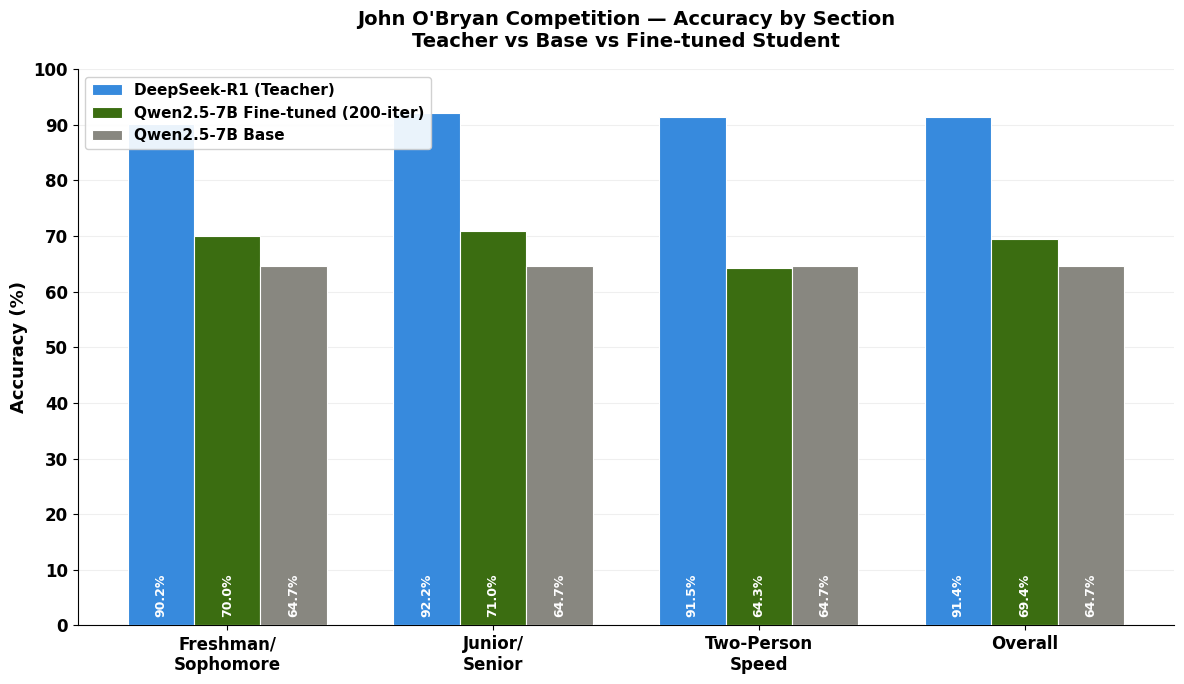

In [32]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 12

sections = ['Freshman/\nSophomore', 'Junior/\nSenior', 'Two-Person\nSpeed', 'Overall']

teacher_vals   = [90.2, 92.2, 91.5, 91.4]
finetuned_vals = [70.0, 71.0, 64.3, 69.43]
base_vals      = [64.67] * 4

x = np.arange(len(sections))
w = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

b1 = ax.bar(x - w, teacher_vals,   w, label='DeepSeek-R1 (Teacher)',            color='#378ADD', edgecolor='white', linewidth=0.8, zorder=3)
b2 = ax.bar(x,     finetuned_vals, w, label='Qwen2.5-7B Fine-tuned (200-iter)', color='#3B6D11', edgecolor='white', linewidth=0.8, zorder=3)
b3 = ax.bar(x + w, base_vals,      w, label='Qwen2.5-7B Base',                  color='#888780', edgecolor='white', linewidth=0.8, zorder=3)

# Labels at the bottom inside bars, rotated
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, 1.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=9, color='white', rotation=90)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, 1.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=9, color='white', rotation=90)
for bar in b3:
    ax.text(bar.get_x() + bar.get_width()/2, 1.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=9, color='white', rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(sections, fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=13)
ax.set_title("John O'Bryan Competition — Accuracy by Section\nTeacher vs Base vs Fine-tuned Student",
             fontweight='bold', fontsize=14, pad=16)
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
for lbl in ax.get_yticklabels(): lbl.set_fontweight('bold')
ax.grid(axis='y', alpha=0.2, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

leg = ax.legend(fontsize=11, loc='upper left', framealpha=0.9, edgecolor='#cccccc')
for t in leg.get_texts(): t.set_fontweight('bold')

fig.tight_layout()
plt.savefig('section_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
for val in df.tail(5).distilled_reasoning:
    print(val)

The largest number not expressible as a nonnegative combination of 7 and 16 is the Frobenius number.  
Since 7 and 16 are coprime, compute \(7 \times 16 - 7 - 16\).  
This gives \(112 - 23 = 89\).  
Thus, \(k = 89\).  

The net is a rectangular grid with 6912 total squares.  
The height \(h\) must be an integer divisor of 6912 between 20 and 30.  
Factor 6912 as \(2^8 \times 3^3\).  
Check divisors in [20,30]: 24 = \(2^3 \times 3\) and 27 = \(3^3\).  
No other integers in that range are divisors.  
Sum the possible heights: \(24 + 27 = 51\).  
Thus, \(w = 51\).  

Add \(k\) and \(w\): \(89 + 51 = 140\).  
Answer: 140
We need Pythagorean triples with 12 as one side, either a leg or the hypotenuse.  
If 12 is a leg, then \(144 + b^2 = c^2\) gives \(c^2 - b^2 = 144\).  
Factor as \((c-b)(c+b) = 144\), with both factors even and positive.  
The even factor pairs of 144 are (2,72), (4,36), (6,24), and (8,18).  
Solving each pair gives the triples (12,35,37), (12,16,20), (12,9,15), and (12,5

In [20]:
df.columns

Index(['year', 'section', 'question_id', 'question', 'true_answer',
       'agent1_answer', 'agent1_reasoning', 'distilled_reasoning',
       'agent2_verdict', 'agent2_justification', 'correct_flag',
       'qwen_response', 'qwen_extracted_answer', 'deepseek_verdict'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671 entries, 0 to 670
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   year                   671 non-null    int64 
 1   section                671 non-null    object
 2   question_id            671 non-null    object
 3   question               671 non-null    object
 4   true_answer            671 non-null    object
 5   agent1_answer          630 non-null    object
 6   agent1_reasoning       651 non-null    object
 7   distilled_reasoning    651 non-null    object
 8   agent2_verdict         671 non-null    object
 9   agent2_justification   671 non-null    object
 10  correct_flag           671 non-null    int64 
 11  qwen_response          671 non-null    object
 12  qwen_extracted_answer  671 non-null    object
 13  deepseek_verdict       671 non-null    object
dtypes: int64(2), object(12)
memory usage: 73.5+ KB


--- Agent 2 Evaluation Summary ---
Overall 'CORRECT' rate (Agent 2): 89.42%

Verdict Breakdown:
agent2_verdict
CORRECT      600
INCORRECT     51
SKIPPED       20
Name: count, dtype: int64


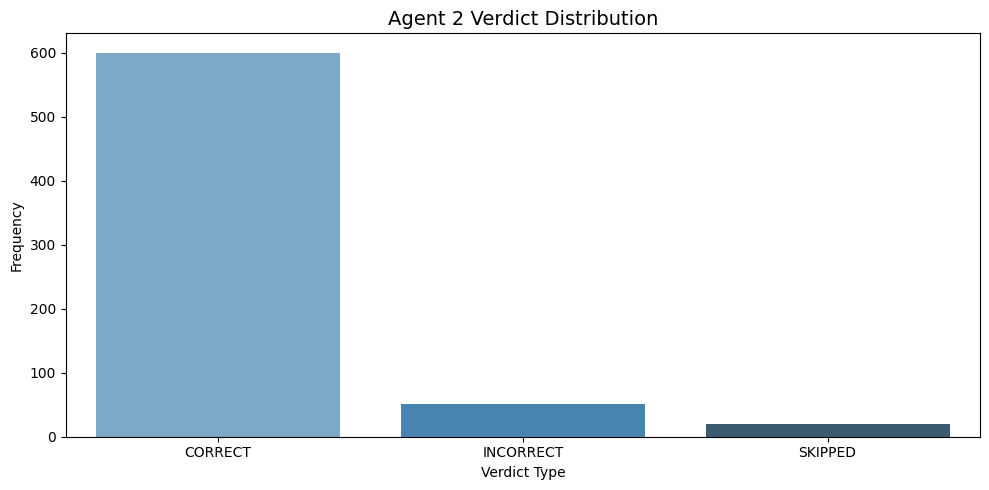

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("qwen_tuned_results.csv")

# Descriptive Analysis - Agent 2
print("--- Agent 2 Evaluation Summary ---")
a2_verdicts = df['agent2_verdict'].value_counts()
a2_correct_pct = (df['agent2_verdict'] == 'CORRECT').mean() * 100

print(f"Overall 'CORRECT' rate (Agent 2): {a2_correct_pct:.2f}%")
print("\nVerdict Breakdown:")
print(a2_verdicts)

# Visualization - Agent 2
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='agent2_verdict', hue='agent2_verdict', palette='Blues_d', legend=False)
plt.title('Agent 2 Verdict Distribution', fontsize=14)
plt.xlabel('Verdict Type')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

--- Qwen tuned Evaluation Summary ---
Overall 'CORRECT' rate (DeepSeek): 65.57%

Verdict Breakdown:
deepseek_verdict
CORRECT                            440
INCORRECT                          210
SKIPPED                             20
JUDGE_ERROR: Request timed out.      1
Name: count, dtype: int64


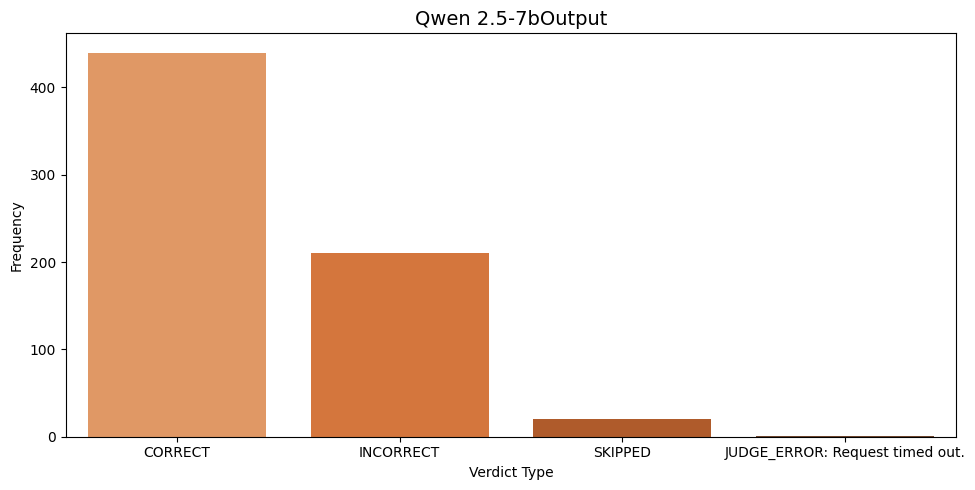

In [23]:
# Descriptive Analysis - DeepSeek
print("--- Qwen tuned Evaluation Summary ---")
ds_verdicts = df['deepseek_verdict'].value_counts()
ds_correct_pct = (df['deepseek_verdict'] == 'CORRECT').mean() * 100

print(f"Overall 'CORRECT' rate (DeepSeek): {ds_correct_pct:.2f}%")
print("\nVerdict Breakdown:")
print(ds_verdicts)

# Visualization - DeepSeek
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='deepseek_verdict', hue='deepseek_verdict', palette='Oranges_d', legend=False)
plt.title('Qwen 2.5-7bOutput', fontsize=14)
plt.xlabel('Verdict Type')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Original rows: 671
Rows after removing timeouts: 670

--- Agent 2 Verdict Counts ---
agent2_verdict
CORRECT      600
INCORRECT     50
SKIPPED       20
Name: count, dtype: int64

--- Qwen tuned Verdict Counts ---
deepseek_verdict
CORRECT      440
INCORRECT    210
SKIPPED       20
Name: count, dtype: int64

--- Verdict Agreement Matrix ---
deepseek_verdict  CORRECT  INCORRECT  SKIPPED
agent2_verdict                               
CORRECT               434        166        0
INCORRECT               6         44        0
SKIPPED                 0          0       20


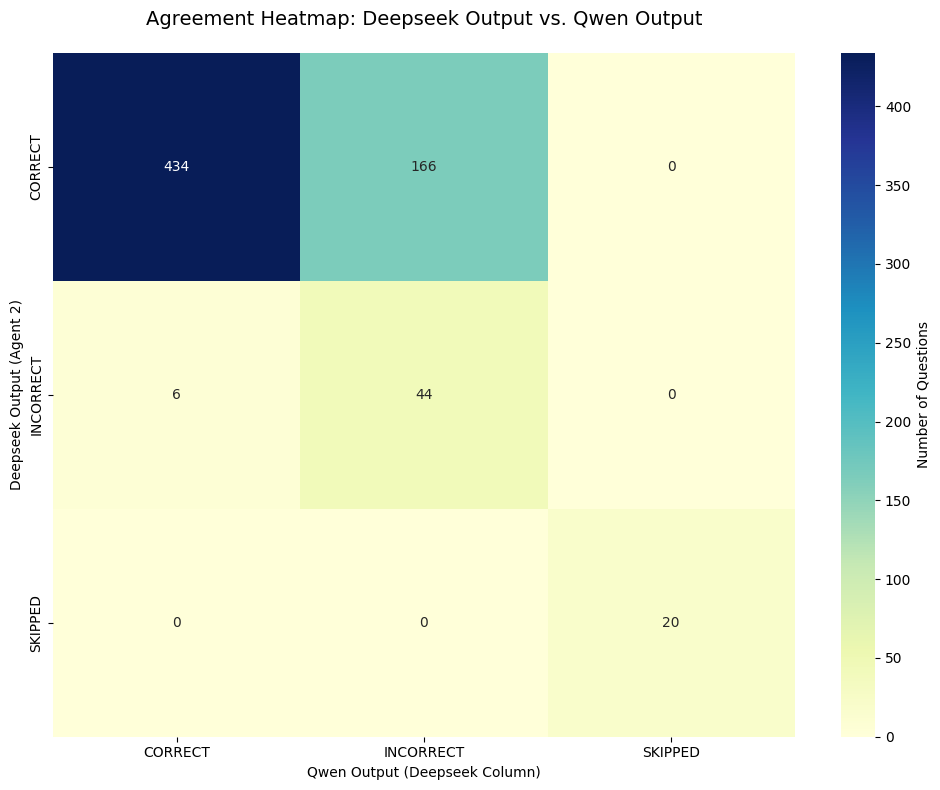

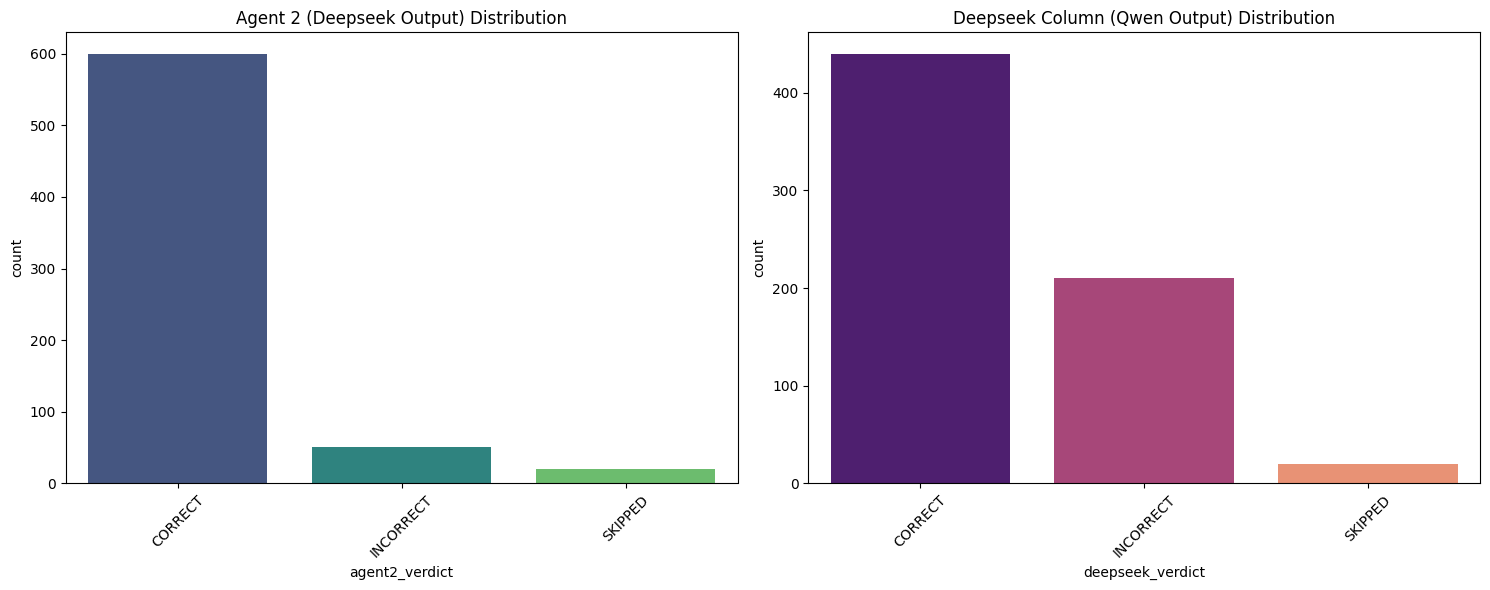

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("qwen_tuned_results.csv")

# 1. Data Cleaning: Remove timeout errors
error_msg = "JUDGE_ERROR: Request timed out."
df_clean = df[(df['agent2_verdict'] != error_msg) & (df['deepseek_verdict'] != error_msg)].copy()

print(f"Original rows: {len(df)}")
print(f"Rows after removing timeouts: {len(df_clean)}")

# 2. Individual Verdict Summaries
print("\n--- Agent 2 Verdict Counts ---")
print(df_clean['agent2_verdict'].value_counts())

print("\n--- Qwen tuned Verdict Counts ---")
print(df_clean['deepseek_verdict'].value_counts())

# 3. Create the Agreement Matrix (Cross-tabulation)
# Based on your request:
# agent2_verdict maps to 'Deepseek Output' (Y-axis)
# deepseek_verdict maps to 'Qwen Output' (X-axis)
comparison = pd.crosstab(df_clean['agent2_verdict'], df_clean['deepseek_verdict'])

print("\n--- Verdict Agreement Matrix ---")
print(comparison)

# 4. Visualization: Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(comparison, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Number of Questions'})

# Setting your requested labels
plt.title('Agreement Heatmap: Deepseek Output vs. Qwen Output', fontsize=14, pad=20)
plt.ylabel('Deepseek Output (Agent 2)')
plt.xlabel('Qwen Output (Deepseek Column)')

plt.tight_layout()
plt.savefig('verdict_heatmap.png')
plt.show()

# 5. Separate Bar Charts for Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(data=df_clean, x='agent2_verdict', ax=ax1, palette='viridis', hue='agent2_verdict', legend=False)
ax1.set_title('Agent 2 (Deepseek Output) Distribution')
ax1.tick_params(axis='x', rotation=45)

sns.countplot(data=df_clean, x='deepseek_verdict', ax=ax2, palette='magma', hue='deepseek_verdict', legend=False)
ax2.set_title('Deepseek Column (Qwen Output) Distribution')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('separate_verdicts.png')
plt.show()

In [26]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/Users/gauurab/Documents/Projects/Distillation.John-O-Bryan/qwen_tuned_results_200iterations.csv")

# Data Cleaning: Remove timeouts AND skipped entries
# This ensures we only look at the actual model performance
error_msg = "JUDGE_ERROR: Request timed out."
df_filtered = df[
    (df['agent2_verdict'] != error_msg) & 
    (df['deepseek_verdict'] != error_msg) &
    (df['deepseek_verdict'] != "SKIPPED")
].copy()

# 1. Distribution Table by Year
year_table = pd.crosstab(df_filtered['year'], df_filtered['deepseek_verdict'])
print("--- Distribution by Year (Excluding Skipped) ---")
print(year_table)

# 2. Distribution Table by Section
section_table = pd.crosstab(df_filtered['section'], df_filtered['deepseek_verdict'])
print("\n--- Distribution by Section (Excluding Skipped) ---")
print(section_table)

# 3. Overall Verdict Distribution
overall_verdict = df_filtered['deepseek_verdict'].value_counts()
overall_percentage = df_filtered['deepseek_verdict'].value_counts(normalize=True) * 100

print("\n--- Overall Verdict Distribution (Excluding Skipped) ---")
overall_df = pd.DataFrame({
    'Count': overall_verdict,
    'Percentage (%)': overall_percentage.round(2)
})
print(overall_df)

# Exporting results
year_table.to_csv("verdict_by_year_no_skipped.csv")
section_table.to_csv("verdict_by_section_no_skipped.csv")
overall_df.to_csv("verdict_overall_no_skipped.csv")

--- Distribution by Year (Excluding Skipped) ---
deepseek_verdict  CORRECT  INCORRECT
year                                
2011                   21         16
2012                   35         15
2013                   32         13
2014                   33         13
2015                   27         16
2016                   32         13
2017                   37          6
2018                   25         18
2019                   19          7
2020                   23         14
2021                   31         15
2022                   32         16
2023                   33         14
2024                   39          9
2025                   33         14

--- Distribution by Section (Excluding Skipped) ---
deepseek_verdict         CORRECT  INCORRECT
section                                    
freshman_sophomore_test      187         80
junior_senior_test           191         78
two_person_speed_event        74         41

--- Overall Verdict Distribution (Excluding Skip